# Structure generation smoke test

This notebook checks the clean and doped slab generators before any calculator is introduced. It uses CIFs from `data/bulk/` when available; otherwise the generator falls back to ASE's fcc reference lattice.

In [ ]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from configs.design_space import HOSTS, DOPANTS, FACETS, DOPANT_COUNTS, CRYSTAL_SETTINGS
from src.structures import HostSlabGenerator, DopedSlabGenerator
from src.structures.utils import get_layer_indices, get_surface_indices, fixed_bottom_layer_indices

print(ROOT)

/Users/iwanpavord/Desktop/SyntheticDataCatKCNODE/data_generation/catalyst_data


## 1. Generate the clean host slabs

Place `Pd.cif`, `Pt.cif`, `Ni.cif`, and `Cu.cif` in `data/bulk/` if you want to use your Materials Project conventional-standard structures.

In [2]:
host_generator = HostSlabGenerator(
    hosts=HOSTS,
    facets=FACETS,
    crystal_settings=CRYSTAL_SETTINGS,
    bulk_dir=ROOT / 'data' / 'bulk',
)

host_slabs = host_generator.generate()
print(f'Generated {len(host_slabs)} clean slabs')
for slab in host_slabs:
    layers = get_layer_indices(slab.atoms)
    print(
        slab.slab_id,
        f'atoms={len(slab.atoms)}',
        f'layers={[len(x) for x in layers]}',
        f'a={slab.metadata["lattice_constant_A"]:.4f} A',
        f'source={slab.metadata["structure_source"]}',
    )

Generated 4 clean slabs
Pd_111_clean atoms=64 layers=[16, 16, 16, 16] a=3.8900 A source=ase_reference
Pt_111_clean atoms=64 layers=[16, 16, 16, 16] a=3.9200 A source=ase_reference
Ni_111_clean atoms=64 layers=[16, 16, 16, 16] a=3.5200 A source=ase_reference
Cu_111_clean atoms=64 layers=[16, 16, 16, 16] a=3.6100 A source=ase_reference


## 2. Basic structural assertions

In [3]:
expected_surface_sites = CRYSTAL_SETTINGS['slab']['supercell'][0] * CRYSTAL_SETTINGS['slab']['supercell'][1]
expected_layers = CRYSTAL_SETTINGS['slab']['n_layers']
expected_fixed_atoms = expected_surface_sites * CRYSTAL_SETTINGS['slab']['fixed_layers']

for slab in host_slabs:
    layers = get_layer_indices(slab.atoms)
    surface = get_surface_indices(slab.atoms)
    fixed = fixed_bottom_layer_indices(slab.atoms, CRYSTAL_SETTINGS['slab']['fixed_layers'])
    assert len(layers) == expected_layers
    assert len(surface) == expected_surface_sites
    assert len(fixed) == expected_fixed_atoms
    assert len(slab.atoms) == expected_surface_sites * expected_layers

print('All clean slab assertions passed.')

All clean slab assertions passed.


## 3. Plot a clean Pt(111) slab from the top and side

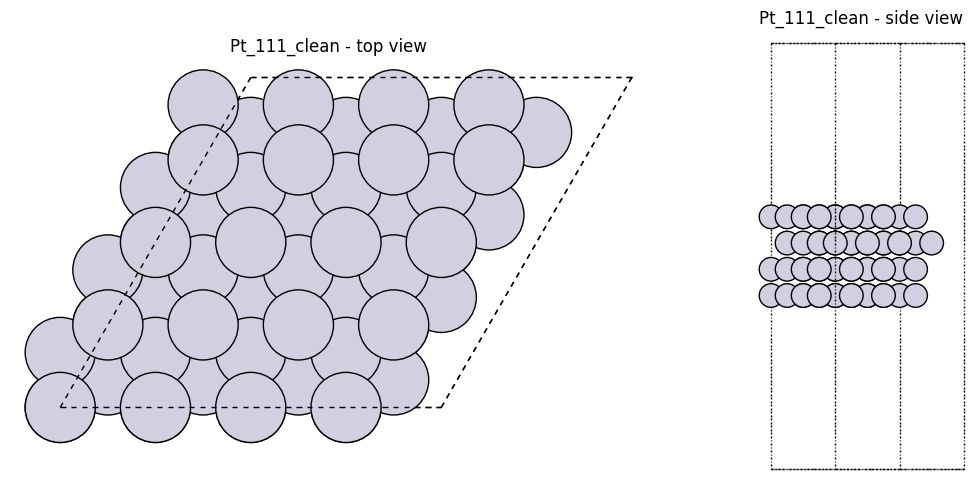

In [4]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

pt111 = next(s for s in host_slabs if s.metadata['host'] == 'Pt')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_atoms(pt111.atoms, axes[0], rotation='0x,0y,0z', radii=0.75)
axes[0].set_title(f'{pt111.slab_id} - top view')
plot_atoms(pt111.atoms, axes[1], rotation='90x,0y,0z', radii=0.75)
axes[1].set_title(f'{pt111.slab_id} - side view')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()

## 4. Generate Cu-doped Pt(111) configurations

The lightweight configuration filter removes many duplicates using periodic dopant-pair distances, then keeps up to `max_configurations_per_composition` arrangements spread from clustered to dispersed.

In [5]:
dopant_generator = DopedSlabGenerator(CRYSTAL_SETTINGS)

examples = {}
for count in [1, 2, 4]:
    configs = dopant_generator.generate(pt111, dopant='Cu', dopant_count=count)
    examples[count] = configs
    print(f'Cu count {count}: {len(configs)} configurations')
    for slab in configs:
        print('  ', slab.slab_id, slab.metadata['dopant_indices'], slab.metadata['dopant_fraction_surface'])

Cu count 1: 1 configurations
   Pt_111_Cu_n1_cfg000 (61,) 0.0625
Cu count 2: 3 configurations
   Pt_111_Cu_n2_cfg000 (61, 60) 0.125
   Pt_111_Cu_n2_cfg001 (61, 59) 0.125
   Pt_111_Cu_n2_cfg002 (61, 55) 0.125
Cu count 4: 5 configurations
   Pt_111_Cu_n4_cfg000 (61, 60, 58, 57) 0.25
   Pt_111_Cu_n4_cfg001 (61, 60, 59, 58) 0.25
   Pt_111_Cu_n4_cfg002 (61, 60, 55, 52) 0.25
   Pt_111_Cu_n4_cfg003 (61, 60, 59, 53) 0.25
   Pt_111_Cu_n4_cfg004 (61, 55, 53, 63) 0.25


## 5. Visual check of the generated dopant arrangements

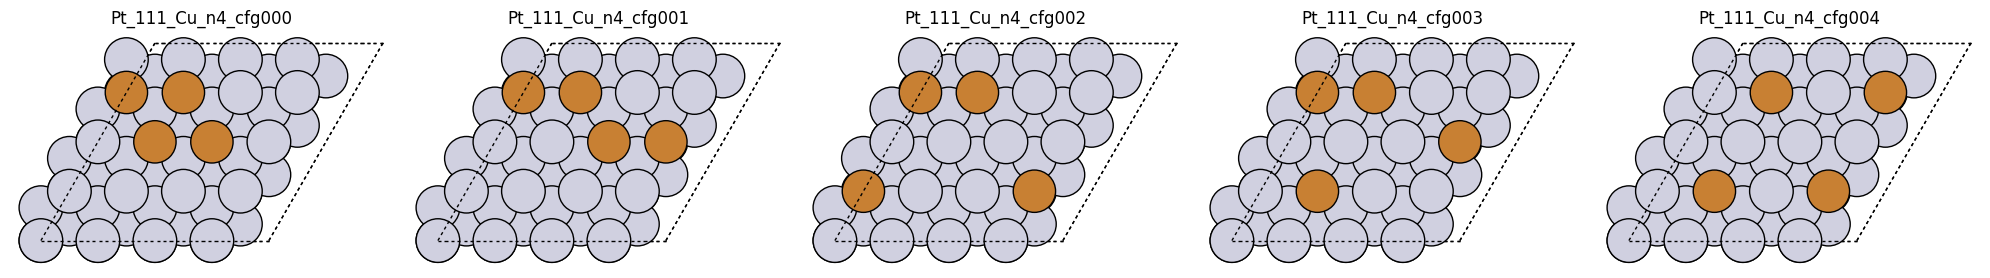

In [6]:
configs = examples[4]
fig, axes = plt.subplots(1, len(configs), figsize=(4 * len(configs), 4))
if len(configs) == 1:
    axes = [axes]

for ax, slab in zip(axes, configs):
    plot_atoms(slab.atoms, ax, rotation='0x,0y,0z', radii=0.78)
    ax.set_title(slab.slab_id)
    ax.set_axis_off()

plt.tight_layout()

## 6. Save a few examples and reload one

In [7]:
output_dir = ROOT / 'data' / 'slabs' / 'initial'
output_dir.mkdir(parents=True, exist_ok=True)

to_save = [pt111, examples[1][0], examples[2][0], examples[4][0]]
for slab in to_save:
    slab.write(output_dir / f'{slab.slab_id}.traj')

from src.structures import Slab
reloaded = Slab.read(output_dir / f'{examples[2][0].slab_id}.traj')
print(reloaded.slab_id)
print(reloaded.metadata)
print(reloaded.atoms.get_chemical_formula())

Pt_111_Cu_n2_cfg000
{'adsorbate_info': {'cell': array([[2.77185858, 0.        ],
       [1.38592929, 2.40049995]]), 'sites': {'ontop': [0, 0], 'bridge': [0.5, 0], 'fcc': [0.3333333333333333, 0.3333333333333333], 'hcp': [0.6666666666666666, 0.6666666666666666]}}, 'host': 'Pt', 'facet': [1, 1, 1], 'dopant': 'Cu', 'dopant_count': 2, 'dopant_fraction_surface': 0.125, 'configuration_id': 0, 'lattice_constant_A': 3.92, 'structure_source': 'ase_reference', 'supercell': [4, 4], 'n_layers': 4, 'fixed_layers': 2, 'vacuum_A': 15.0, 'dopant_indices': [61, 60]}
Cu2Pt62
